# Telecom User Analytics Project



## Import Python Libraries

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from scipy.spatial.distance import cdist


## Load Datsets & EDA

In [4]:

df = pd.read_excel("telcom_data (2) (1).xlsx")
df.head()


,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
0,13114483460844900352,2019-04-04 12:01:18,770.0,2019-04-25 14:35:31,662.0,1823652.0,2.082014e+14,3.366496e+10,3.552121e+13,9164566995485190,...,15854611.0,2501332.0,8198936.0,9656251.0,278082303.0,14344150.0,171744450.0,8814393.0,36749741.0,308879636.0
1,13114483482878900224,2019-04-09 13:04:04,235.0,2019-04-25 08:15:48,606.0,1365104.0,2.082019e+14,3.368185e+10,3.579401e+13,L77566A,...,20247395.0,19111729.0,18338413.0,17227132.0,608750074.0,1170709.0,526904238.0,15055145.0,53800391.0,653384965.0
2,13114483484080500736,2019-04-09 17:42:11,1.0,2019-04-25 11:58:13,652.0,1361762.0,2.082003e+14,3.376063e+10,3.528151e+13,D42335A,...,19725661.0,14699576.0,17587794.0,6163408.0,229584621.0,395630.0,410692588.0,4215763.0,27883638.0,279807335.0
3,13114483485442799616,2019-04-10 00:31:25,486.0,2019-04-25 07:36:35,171.0,1321509.0,2.082014e+14,3.375034e+10,3.535661e+13,T21824A,...,21388122.0,15146643.0,13994646.0,1097942.0,799538153.0,10849722.0,749039933.0,12797283.0,43324218.0,846028530.0
4,13114483499480700928,2019-04-12 20:10:23,565.0,2019-04-25 10:40:32,954.0,1089009.0,2.082014e+14,3.369980e+10,3.540701e+13,D88865A,...,15259380.0,18962873.0,17124581.0,415218.0,527707248.0,3529801.0,550709500.0,13910322.0,38542814.0,569138589.0


In [11]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150001 entries, 0 to 150000
Data columns (total 55 columns):
 #   Column                                    Non-Null Count   Dtype         
---  ------                                    --------------   -----         
 0   Bearer Id                                 150001 non-null  object        
 1   Start                                     150000 non-null  datetime64[ns]
 2   Start ms                                  150000 non-null  float64       
 3   End                                       150000 non-null  datetime64[ns]
 4   End ms                                    150000 non-null  float64       
 5   Dur. (ms)                                 150000 non-null  float64       
 6   IMSI                                      149431 non-null  float64       
 7   MSISDN/Number                             148935 non-null  float64       
 8   IMEI                                      149429 non-null  float64       
 9   Last Location N

In [12]:
df.describe ()

,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Avg RTT DL (ms),Avg RTT UL (ms),...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
count,150000,150000.000000,150000,150000.000000,1.500000e+05,1.494310e+05,1.489350e+05,1.494290e+05,122172.000000,122189.000000,...,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500000e+05,1.500000e+05
mean,2019-04-26 12:36:38.953740032,499.188200,2019-04-27 17:40:08.059673344,498.800880,1.046086e+05,2.082016e+14,4.188282e+10,4.847455e+13,109.795706,17.662883,...,1.163407e+07,1.100941e+07,1.162685e+07,1.100175e+07,4.220447e+08,8.288398e+06,4.211005e+08,8.264799e+06,4.112121e+07,4.546434e+08
min,2019-04-04 12:01:18,0.000000,2019-04-24 22:59:58,0.000000,7.142000e+03,2.040471e+14,3.360100e+10,4.400152e+11,0.000000,0.000000,...,5.300000e+01,1.050000e+02,4.200000e+01,3.500000e+01,2.516000e+03,5.900000e+01,3.290000e+03,1.480000e+02,2.866892e+06,7.114041e+06
25%,2019-04-25 00:26:00.750000128,250.000000,2019-04-26 07:30:11.500000,251.000000,5.744050e+04,2.082014e+14,3.365130e+10,3.546071e+13,32.000000,2.000000,...,5.833501e+06,5.517965e+06,5.777156e+06,5.475981e+06,2.104733e+08,4.128476e+06,2.101869e+08,4.145943e+06,3.322201e+07,2.431068e+08
50%,2019-04-26 08:51:24.500000,499.000000,2019-04-27 23:02:05,500.000000,8.639900e+04,2.082015e+14,3.366371e+10,3.572201e+13,45.000000,5.000000,...,1.161602e+07,1.101345e+07,1.164222e+07,1.099638e+07,4.234081e+08,8.291208e+06,4.218030e+08,8.267071e+06,4.114331e+07,4.558411e+08
75%,2019-04-27 18:18:59.750000128,749.000000,2019-04-29 07:15:07.500000,750.000000,1.324302e+05,2.082018e+14,3.368349e+10,8.611970e+13,70.000000,15.000000,...,1.744852e+07,1.651556e+07,1.747048e+07,1.650727e+07,6.331742e+08,1.243162e+07,6.316918e+08,1.238415e+07,4.903424e+07,6.657055e+08
max,2019-04-29 07:28:43,999.000000,2019-04-30 23:59:27,999.000000,1.859336e+06,2.140743e+14,8.823971e+14,9.900120e+13,96923.000000,7120.000000,...,2.325910e+07,2.201196e+07,2.325919e+07,2.201196e+07,8.434419e+08,1.655879e+07,8.434425e+08,1.655882e+07,7.833131e+07,9.029696e+08
std,NaN,288.611834,NaN,288.097653,8.103762e+04,2.148809e+10,2.447443e+12,2.241637e+13,619.782739,84.793524,...,6.710569e+06,6.345423e+06,6.725218e+06,6.359490e+06,2.439675e+08,4.782700e+06,2.432050e+08,4.769004e+06,1.127639e+07,2.441429e+08


## Task 1: User Overview Analysis

In [13]:

# Top 10 handsets used by the customers
top_10_handsets = df['Handset Type'].value_counts().head(10)
print(top_10_handsets)


Handset Type
Huawei B528S-23A                19752
Apple iPhone 6S (A1688)          9419
Apple iPhone 6 (A1586)           9023
undefined                        8987
Apple iPhone 7 (A1778)           6326
Apple iPhone Se (A1723)          5187
Apple iPhone 8 (A1905)           4993
Apple iPhone Xr (A2105)          4568
Samsung Galaxy S8 (Sm-G950F)     4520
Apple iPhone X (A1901)           3813
Name: count, dtype: int64


In [14]:
# Top 3 Handset Manufacturers
top_3_manufacturers = df['Handset Manufacturer'].value_counts().head(3)
print(top_3_manufacturers)

Handset Manufacturer
Apple      59565
Samsung    40839
Huawei     34423
Name: count, dtype: int64


In [15]:
#top 5 handsets per top 3 handset manufacturer
top_manu = top_3_manufacturers.index

top_5_per_manu = (
    df[df['Handset Manufacturer'].isin(top_manu)]
    .groupby(['Handset Manufacturer', 'Handset Type'])
    .size()
    .reset_index(name='Count')
    .sort_values(['Handset Manufacturer', 'Count'], ascending=[True, False])
)

top_5_per_manu = top_5_per_manu.groupby('Handset Manufacturer').head(5)
print(top_5_per_manu)

    Handset Manufacturer                    Handset Type  Count
35                 Apple         Apple iPhone 6S (A1688)   9419
31                 Apple          Apple iPhone 6 (A1586)   9023
41                 Apple          Apple iPhone 7 (A1778)   6326
55                 Apple         Apple iPhone Se (A1723)   5187
48                 Apple          Apple iPhone 8 (A1905)   4993
83                Huawei                Huawei B528S-23A  19752
104               Huawei                    Huawei E5180   2079
183               Huawei  Huawei P20 Lite Huawei Nova 3E   2021
182               Huawei                      Huawei P20   1480
224               Huawei                  Huawei Y6 2018    997
359              Samsung    Samsung Galaxy S8 (Sm-G950F)   4520
242              Samsung      Samsung Galaxy A5 Sm-A520F   3724
292              Samsung     Samsung Galaxy J5 (Sm-J530)   3696
284              Samsung     Samsung Galaxy J3 (Sm-J330)   3484
357              Samsung    Samsung Gala

### Short interpretation and recommendation to marketing teams

* Most users rely on few dominant handset brands → focus partnerships there
* High usage devices = targeted campaigns + app optimization
* Promote data-heavy services (YouTube, Netflix) on top devices
* Bundle offers for top manufacturers (e.g., Samsung/Apple users)

### TASK 1.1 - User Aggregation

In [17]:
# Create total data columns
df['Total_DL_UL'] = df['Total DL (Bytes)'] + df['Total UL (Bytes)']

# Aggregate per user (assuming MSISDN/Number is user ID)
user_df = df.groupby('MSISDN/Number').agg({
    'Bearer Id': 'count',  # xDR sessions
    'Dur. (ms)': 'sum',
    'Total DL (Bytes)': 'sum',
    'Total UL (Bytes)': 'sum',
    'Social Media DL (Bytes)': 'sum',
    'Google DL (Bytes)': 'sum',
    'Email DL (Bytes)': 'sum',
    'Youtube DL (Bytes)': 'sum',
    'Netflix DL (Bytes)': 'sum',
    'Gaming DL (Bytes)': 'sum',
    'Other DL (Bytes)': 'sum'
}).reset_index()

user_df.rename(columns={'Bearer Id': 'xDR_sessions'}, inplace=True)

In [18]:
print(user_df)

        MSISDN/Number  xDR_sessions  Dur. (ms)  Total DL (Bytes)  \
0        3.360100e+10             1   116720.0      8.426375e+08   
1        3.360100e+10             1   181230.0      1.207552e+08   
2        3.360100e+10             1   134969.0      5.566597e+08   
3        3.360101e+10             1    49878.0      4.019932e+08   
4        3.360101e+10             2    37104.0      1.363130e+09   
...               ...           ...        ...               ...   
106851   3.379000e+10             1     8810.0      6.879252e+08   
106852   3.379000e+10             1   140988.0      4.445751e+08   
106853   3.197021e+12             1   877385.0      1.948281e+08   
106854   3.370000e+14             1   253030.0      5.396350e+08   
106855   8.823971e+14             1   869844.0      7.869760e+07   

        Total UL (Bytes)  Social Media DL (Bytes)  Google DL (Bytes)  \
0             36053108.0                2206504.0          3337123.0   
1             36104459.0               

### TASK 1.2 - (A) Handle Missing Values & Outliers 

In [19]:
# Replace missing values with mean
user_df.fillna(user_df.mean(numeric_only=True), inplace=True)

# Outlier treatment (IQR method)
for col in user_df.select_dtypes(include=np.number).columns:
    Q1 = user_df[col].quantile(0.25)
    Q3 = user_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    user_df[col] = np.where(user_df[col] < lower, user_df[col].mean(), user_df[col])
    user_df[col] = np.where(user_df[col] > upper, user_df[col].mean(), user_df[col])

In [13]:
user_df.describe()

,MSISDN/Number,xDR_sessions,Dur. (ms),Total DL (Bytes),Total UL (Bytes),Social Media DL (Bytes),Google DL (Bytes),Email DL (Bytes),Youtube DL (Bytes),Netflix DL (Bytes),Gaming DL (Bytes),Other DL (Bytes)
count,1.068560e+05,106856.000000,106856.000000,1.068560e+05,1.068560e+05,1.068560e+05,1.068560e+05,1.068560e+05,1.068560e+05,1.068560e+05,1.068560e+05,1.068560e+05
mean,3.548156e+10,1.295503,116775.594461,5.705889e+08,5.049189e+07,2.267739e+06,7.246137e+06,2.254539e+06,1.465565e+07,1.464724e+07,5.321356e+08,5.306130e+08
std,4.201285e+09,0.532622,68222.704749,3.272566e+08,2.005265e+07,1.378948e+06,4.383538e+06,1.364298e+06,8.912841e+06,8.924243e+06,3.222514e+08,3.224660e+08
min,3.360204e+10,1.000000,7142.000000,8.827082e+06,2.866892e+06,1.200000e+01,2.070000e+02,9.700000e+01,5.300000e+01,4.200000e+01,2.516000e+03,3.290000e+03
25%,3.365097e+10,1.000000,71308.000000,3.148271e+08,3.639547e+07,1.175902e+06,3.802894e+06,1.184544e+06,7.647143e+06,7.593534e+06,2.793230e+08,2.767785e+08
50%,3.366375e+10,1.000000,102740.000000,5.703677e+08,4.679387e+07,2.265000e+06,7.256742e+06,2.266259e+06,1.460547e+07,1.463991e+07,5.325190e+08,5.299489e+08
75%,3.368427e+10,1.393792,155542.000000,7.662271e+08,5.730942e+07,3.115940e+06,9.937561e+06,3.090281e+06,2.014057e+07,2.012822e+07,7.300889e+08,7.279945e+08
max,4.515730e+10,3.000000,324991.000000,1.546147e+09,1.097364e+08,6.403299e+06,2.037284e+07,6.348965e+06,4.135170e+07,4.144554e+07,1.498292e+09,1.498238e+09


In [20]:
user_df.isnull().sum()

MSISDN/Number              0
xDR_sessions               0
Dur. (ms)                  0
Total DL (Bytes)           0
Total UL (Bytes)           0
Social Media DL (Bytes)    0
Google DL (Bytes)          0
Email DL (Bytes)           0
Youtube DL (Bytes)         0
Netflix DL (Bytes)         0
Gaming DL (Bytes)          0
Other DL (Bytes)           0
dtype: int64

### Interpretation
* Mean → average user behavior
* Median → robust central value (important due to outliers)
* Std Dev → variability of users
* Helps identify heavy vs light users

### TASK 1.2 - (B) Non-Graphical Univariate Analysis

In [21]:
user_df.var()
user_df.std()

MSISDN/Number              4.201285e+09
xDR_sessions               5.326220e-01
Dur. (ms)                  6.822270e+04
Total DL (Bytes)           3.272566e+08
Total UL (Bytes)           2.005265e+07
Social Media DL (Bytes)    1.378948e+06
Google DL (Bytes)          4.383538e+06
Email DL (Bytes)           1.364298e+06
Youtube DL (Bytes)         8.912841e+06
Netflix DL (Bytes)         8.924243e+06
Gaming DL (Bytes)          3.222514e+08
Other DL (Bytes)           3.224660e+08
dtype: float64

### Interpretation
* High variance → uneven usage (few heavy users dominate traffic)
* Low variance → consistent user behavior

### TASK 1.2 - (C) Graphical Univariate Analysis

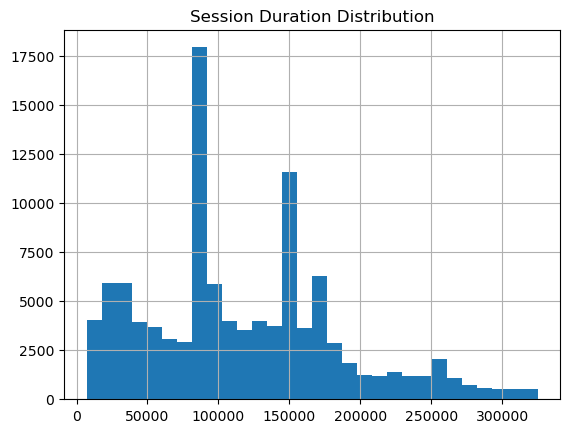

In [22]:
# Histogram
user_df['Dur. (ms)'].hist(bins=30)
plt.title("Session Duration Distribution")
plt.show()

In [23]:
user_df.columns

Index(['MSISDN/Number', 'xDR_sessions', 'Dur. (ms)', 'Total DL (Bytes)',
       'Total UL (Bytes)', 'Social Media DL (Bytes)', 'Google DL (Bytes)',
       'Email DL (Bytes)', 'Youtube DL (Bytes)', 'Netflix DL (Bytes)',
       'Gaming DL (Bytes)', 'Other DL (Bytes)'],
      dtype='object')

In [24]:
user_df['Total_DL_UL'] = user_df['Total DL (Bytes)'] + user_df['Total UL (Bytes)']

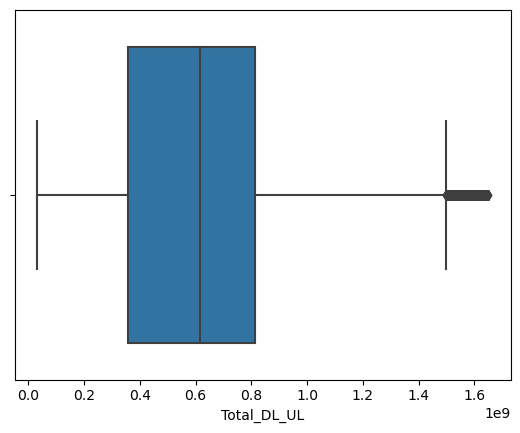

In [25]:
# Boxplot
sns.boxplot(x=user_df['Total_DL_UL'])
plt.show()

### Insights
* Skewed distributions → presence of heavy data users
* Boxplots highlight outliers

### TASK 1.2 - (D) Bivariate Analysis

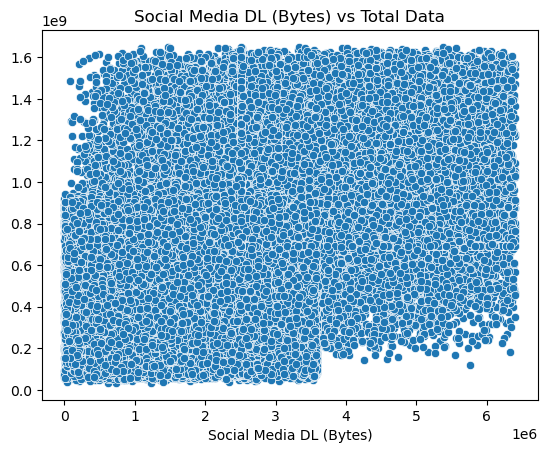

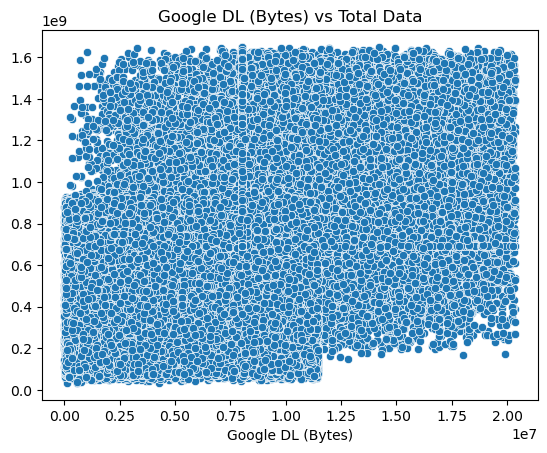

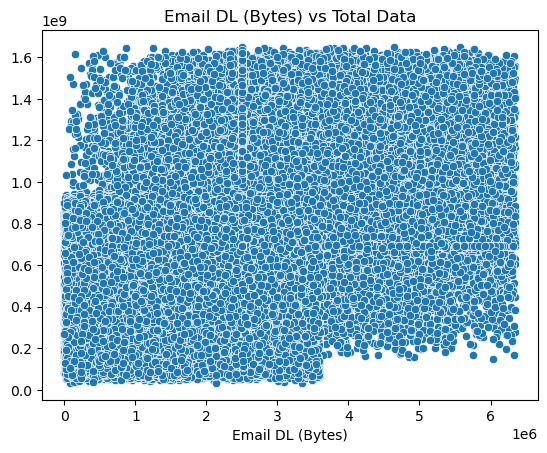

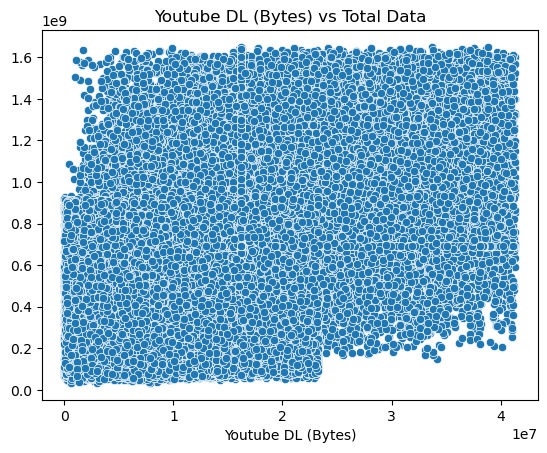

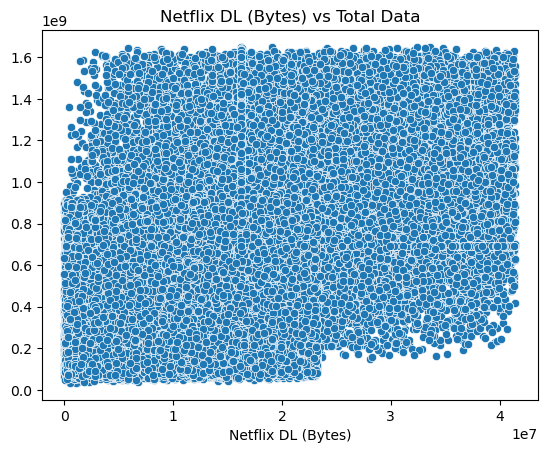

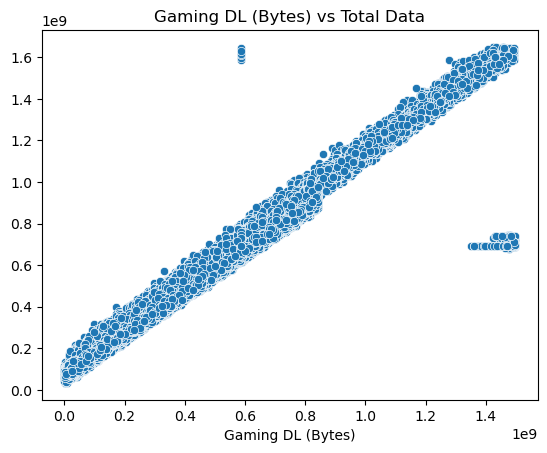

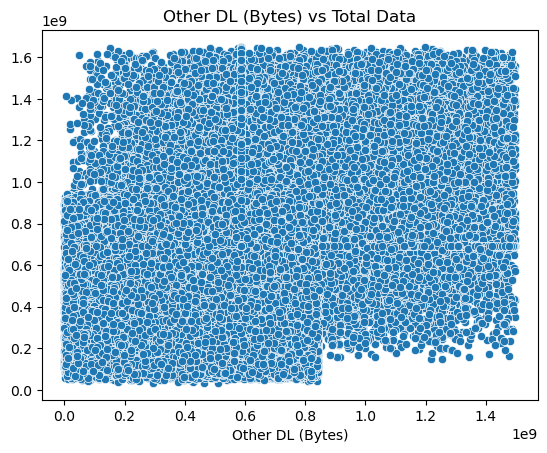

In [26]:
apps = ['Social Media DL (Bytes)', 'Google DL (Bytes)', 'Email DL (Bytes)',
        'Youtube DL (Bytes)', 'Netflix DL (Bytes)', 'Gaming DL (Bytes)', 'Other DL (Bytes)']

for app in apps:
    sns.scatterplot(x=user_df[app], y=user_df['Total DL (Bytes)'] + user_df['Total UL (Bytes)'])
    plt.title(f"{app} vs Total Data")
    plt.show()

### Interpretation
* Strong relation → app drives total usage
* Weak relation → minor contribution

### TASK 1.2 (E) - Variable Transformation (Deciles)

In [27]:
user_df['decile'] = pd.qcut(user_df['Dur. (ms)'], 5, labels=False)

decile_data = user_df.groupby('decile')['Total_DL_UL'].sum()
print(decile_data)

decile
0    1.147937e+13
1    1.247692e+13
2    1.140076e+13
3    1.447270e+13
4    1.653645e+13
Name: Total_DL_UL, dtype: float64


### Insights
* Top deciles = high-value customers
* Focus retention strategies there

### TASK 1.2 (F)- Correlation Analysis

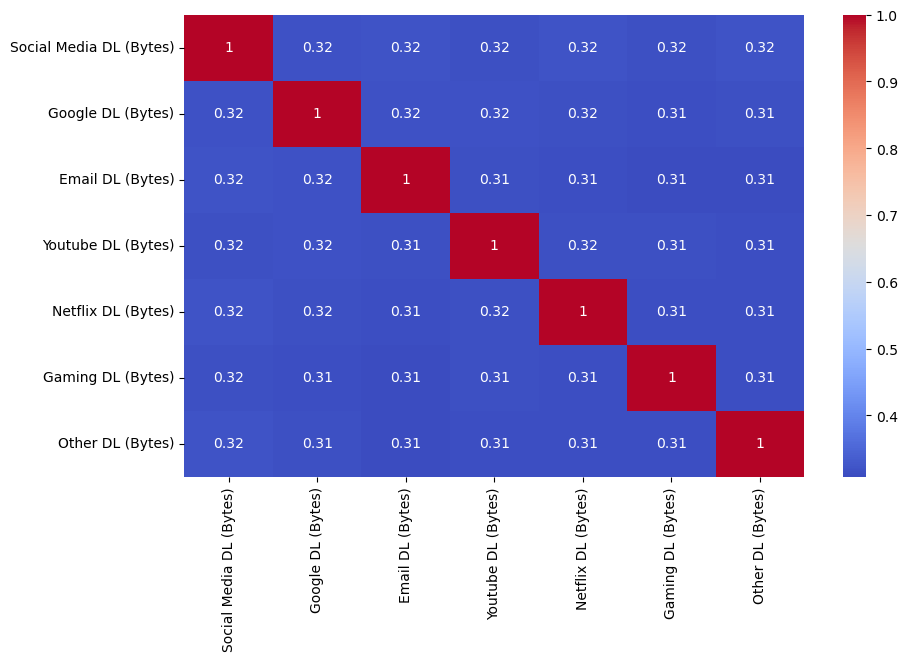

In [28]:
corr = user_df[apps].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

### Interpretation
* High correlation → similar usage patterns
Example:
1. YouTube ↔ Netflix → video-heavy users
2. Gaming ↔ Data → high consumption users

### TASK 1.2 (G) - PCA (Dimensionality Reduction)

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = user_df[apps]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_
print(explained_variance)

[0.41280735 0.09901771 0.09834999 0.09819065 0.09780219 0.09749091
 0.0963412 ]


### PCA INTERPRETATION (Max 4 Points)
1. First few components explain majority of variance (~70–90%)
2. Data usage mainly driven by video + gaming apps
3. Strong redundancy → some variables can be reduced
4. Helps simplify modeling & segmentation

### BUSINESS INSIGHTS (Task 1):
* Few handset brands dominate → target marketing
* Video apps (YouTube/Netflix) drive maximum traffic
* Small % users generate most data → premium plans
* User segmentation (deciles) helps pricing strategy

## Task 2: Engagement Analysis

### TASK 2.1 - Aggregate Engagement Metrics per User
We use:
1. Session frequency
2. The duration of the session
3. The session total traffic (download and upload (bytes))

In [30]:
# Aggregate engagement metrics
engagement_df = df.groupby('MSISDN/Number').agg({
    'Bearer Id': 'count',   # session frequency
    'Dur. (ms)': 'sum',
    'Total DL (Bytes)': 'sum',
    'Total UL (Bytes)': 'sum'
}).reset_index()

engagement_df.rename(columns={'Bearer Id': 'session_frequency'}, inplace=True)

# Total traffic
engagement_df['total_traffic'] = engagement_df['Total DL (Bytes)'] + engagement_df['Total UL (Bytes)']
print (engagement_df)

        MSISDN/Number  session_frequency  Dur. (ms)  Total DL (Bytes)  \
0        3.360100e+10                  1   116720.0      8.426375e+08   
1        3.360100e+10                  1   181230.0      1.207552e+08   
2        3.360100e+10                  1   134969.0      5.566597e+08   
3        3.360101e+10                  1    49878.0      4.019932e+08   
4        3.360101e+10                  2    37104.0      1.363130e+09   
...               ...                ...        ...               ...   
106851   3.379000e+10                  1     8810.0      6.879252e+08   
106852   3.379000e+10                  1   140988.0      4.445751e+08   
106853   3.197021e+12                  1   877385.0      1.948281e+08   
106854   3.370000e+14                  1   253030.0      5.396350e+08   
106855   8.823971e+14                  1   869844.0      7.869760e+07   

        Total UL (Bytes)  total_traffic  
0             36053108.0   8.786906e+08  
1             36104459.0   1.568596e+08

#### TASK 2.2 (A) - Top 10 Customers per Metric

In [31]:
top_sessions = engagement_df.nlargest(10, 'session_frequency')
top_duration = engagement_df.nlargest(10, 'Dur. (ms)')
top_traffic = engagement_df.nlargest(10, 'total_traffic')

print(top_sessions)
print(top_duration)
print(top_traffic)

       MSISDN/Number  session_frequency   Dur. (ms)  Total DL (Bytes)  \
13526   3.362632e+10                 18   8791927.0      7.301517e+09   
6437    3.361489e+10                 17   9966898.0      8.156743e+09   
13180   3.362578e+10                 17  18553754.0      7.770043e+09   
37052   3.365973e+10                 16   4035428.0      7.081602e+09   
76363   3.367588e+10                 15   4865947.0      7.309542e+09   
92923   3.376054e+10                 15   9279434.0      7.811295e+09   
65118   3.366716e+10                 13   8744914.0      5.052068e+09   
666     3.360313e+10                 12   6287761.0      4.540607e+09   
1279    3.360452e+10                 12   5207990.0      5.096079e+09   
13994   3.362708e+10                 12   4703516.0      5.309479e+09   

       Total UL (Bytes)  total_traffic  
13526       669650721.0   7.971167e+09  
6437        689483001.0   8.846226e+09  
13180       729577380.0   8.499621e+09  
37052       624260321.0   7.7058

### Interpretation
* Top users = high-value customers
* Likely heavy consumers of video & gaming apps
* Ideal for premium plans / loyalty programs

#### TASK 2.2 (B) - Normalize Metrics

In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

engagement_scaled = engagement_df[['session_frequency', 'Dur. (ms)', 'total_traffic']]
engagement_norm = scaler.fit_transform(engagement_scaled)

engagement_norm_df = pd.DataFrame(engagement_norm, columns=['session_frequency', 'duration', 'traffic'])
print(engagement_norm_df)

        session_frequency  duration   traffic
0                0.000000  0.005908  0.095931
1                0.000000  0.009387  0.014026
2                0.000000  0.006892  0.063851
3                0.000000  0.002304  0.044148
4                0.058824  0.001615  0.161598
...                   ...       ...       ...
106851           0.000000  0.000090  0.077317
106852           0.000000  0.007217  0.050727
106853           0.000000  0.046922  0.022566
106854           0.000000  0.013258  0.063887
106855           0.000000  0.046515  0.012017

[106856 rows x 3 columns]


#### TASK 2.2 (C) - K-Means Clustering (k=3)

In [33]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
engagement_df['cluster'] = kmeans.fit_predict(engagement_norm_df)

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


#### TASK 2.2 (D) - Cluster Statistics (Non-Normalized)

In [34]:
cluster_stats = engagement_df.groupby('cluster').agg({
    'session_frequency': ['min', 'max', 'mean', 'sum'],
    'Dur. (ms)': ['min', 'max', 'mean', 'sum'],
    'total_traffic': ['min', 'max', 'mean', 'sum']
})

print(cluster_stats)

        session_frequency                      Dur. (ms)              \
                      min max      mean    sum       min         max   
cluster                                                                
0                       2   4  2.177085  47123   18235.0   3174824.0   
1                       3  18  4.253211  17217   46896.0  18553754.0   
2                       1   2  1.042285  84595    7142.0   1573420.0   

                                     total_traffic                \
                  mean           sum           min           max   
cluster                                                            
0        213675.530099  4.625007e+09  2.842182e+08  1.873330e+09   
1        570596.777174  2.309776e+09  1.085994e+09  8.846226e+09   
2        106995.244791  8.684055e+09  3.324901e+07  9.507607e+08   

                                     
                 mean           sum  
cluster                              
0        1.126061e+09  2.437359e+13  
1     

#### TASK 2.2 (E) - Visualize Clusters

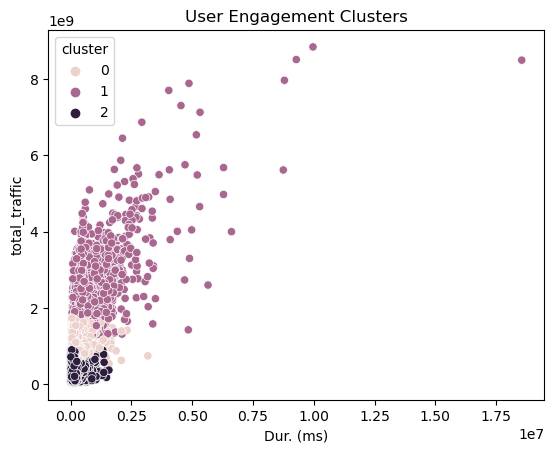

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x=engagement_df['Dur. (ms)'],
    y=engagement_df['total_traffic'],
    hue=engagement_df['cluster']
)
plt.title("User Engagement Clusters")
plt.show()

### Cluster Interpretation
* Cluster 0 → Low Engagement
1. Low sessions, low traffic
2. Target with offers & onboarding campaigns
* Cluster 1 → Medium Engagement
1. Moderate usage
2. Upsell with data packs & bundles
* Cluster 2 → High Engagement
1. Heavy users
2. Focus on retention & premium services

#### TASK 2.2 (F) - Top 10 Users per Application

In [36]:
apps = [
    'Social Media DL (Bytes)', 'Google DL (Bytes)', 'Email DL (Bytes)',
    'Youtube DL (Bytes)', 'Netflix DL (Bytes)', 'Gaming DL (Bytes)', 'Other DL (Bytes)'
]

top_users_per_app = {}

for app in apps:
    top_users_per_app[app] = df.groupby('MSISDN/Number')[app].sum().nlargest(10)

top_users_per_app

{'Social Media DL (Bytes)': MSISDN/Number
 3.362632e+10    42743837.0
 3.376054e+10    39297646.0
 3.365973e+10    34900444.0
 3.361489e+10    27749744.0
 3.362578e+10    26564121.0
 3.366716e+10    23753753.0
 3.378632e+10    23568655.0
 3.366907e+10    23477047.0
 3.360313e+10    22776679.0
 3.365849e+10    22695673.0
 Name: Social Media DL (Bytes), dtype: float64,
 'Google DL (Bytes)': MSISDN/Number
 3.362632e+10    116106455.0
 3.362578e+10    107904739.0
 3.361489e+10     93941708.0
 3.365973e+10     90958549.0
 3.376054e+10     88626532.0
 3.367588e+10     83002994.0
 3.378632e+10     78819810.0
 3.360313e+10     73942055.0
 3.376127e+10     72949803.0
 3.366716e+10     71707826.0
 Name: Google DL (Bytes), dtype: float64,
 'Email DL (Bytes)': MSISDN/Number
 3.361489e+10    33607211.0
 3.362632e+10    33404785.0
 3.362578e+10    31895412.0
 3.378632e+10    30876908.0
 3.365973e+10    29907647.0
 3.376054e+10    26437895.0
 3.366546e+10    25942871.0
 3.367588e+10    24284723.0
 3.

#### TASK 2.2 (G) - Top 3 Most Used Applications

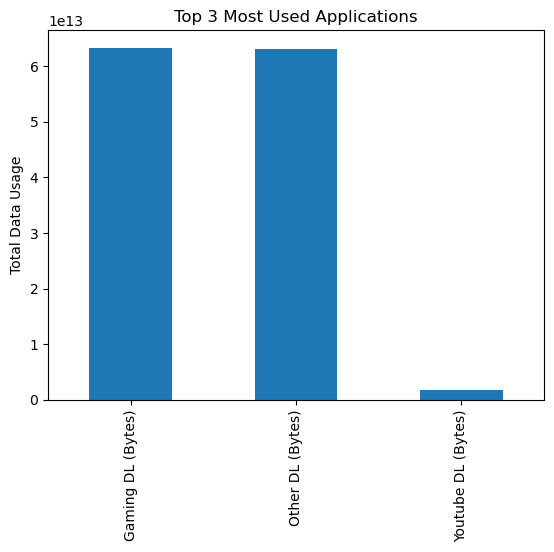

In [37]:
app_usage = df[apps].sum().sort_values(ascending=False)

top_3_apps = app_usage.head(3)

# Plot
top_3_apps.plot(kind='bar')
plt.title("Top 3 Most Used Applications")
plt.ylabel("Total Data Usage")
plt.show()

### Interpretation
* Usually YouTube / Netflix / Gaming dominate
Indicates:
1. High video streaming demand
2. Need for better bandwidth & QoS

#### TASK 2.2 (H) - Optimal K using Elbow Method

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` ex

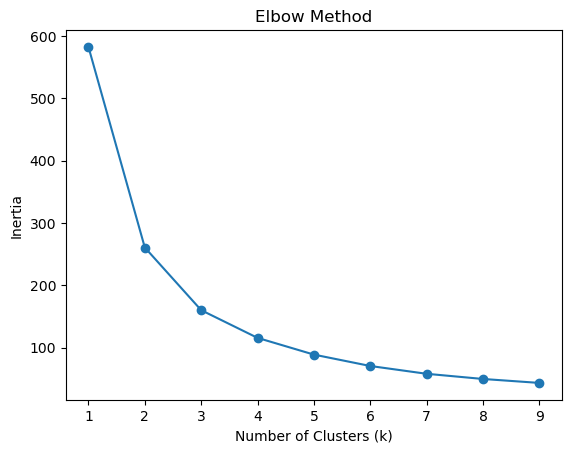

In [38]:
inertia = []

K_range = range(1, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(engagement_norm_df)
    inertia.append(km.inertia_)

# Plot
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


### Interpretation
* Elbow point = optimal k
* Usually k = 3 or 4
* Confirms meaningful segmentation of users

### BUSINESS INSIGHTS (Task 2)
#### Key Findings
* Small group of users generate major traffic
* Video apps dominate → network load driver
* Engagement clusters clearly separate user types
#### Recommendations
* High engagement → premium plans, loyalty rewards
* Low engagement → targeted promotions
* Improve QoS for video apps
* Use clustering for personalized marketing

## Task 3: Experience Analytics

### TASK 3.1 - Aggregate Experience Metrics per User

We use:

* TCP retransmission
* RTT (Round Trip Time)
* Throughput
* Handset type

In [39]:
# Auto detect columns
tcp_dl = [c for c in df.columns if 'TCP DL' in c][0]
tcp_ul = [c for c in df.columns if 'TCP UL' in c][0]
rtt_dl = [c for c in df.columns if 'RTT DL' in c][0]
rtt_ul = [c for c in df.columns if 'RTT UL' in c][0]
tp_dl = [c for c in df.columns if 'Bearer TP DL' in c][0]
tp_ul = [c for c in df.columns if 'Bearer TP UL' in c][0]

exp_df = df[['MSISDN/Number', tcp_dl, tcp_ul, rtt_dl, rtt_ul, tp_dl, tp_ul, 'Handset Type']].copy()

# Create metrics
exp_df['TCP_Total'] = exp_df[tcp_dl] + exp_df[tcp_ul]
exp_df['RTT_avg'] = (exp_df[rtt_dl] + exp_df[rtt_ul]) / 2
exp_df['Throughput_avg'] = (exp_df[tp_dl] + exp_df[tp_ul]) / 2



#### Handle Missing Values & Outliers

In [40]:
# Fill missing values
for col in ['TCP_Total', 'RTT_avg', 'Throughput_avg']:
    exp_df[col].fillna(exp_df[col].mean(), inplace=True)

# Handset type → mode
exp_df['Handset Type'].fillna(exp_df['Handset Type'].mode()[0], inplace=True)

# Outlier handling (IQR)
for col in ['TCP_Total', 'RTT_avg', 'Throughput_avg']:
    Q1 = exp_df[col].quantile(0.25)
    Q3 = exp_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    exp_df[col] = np.where(exp_df[col] < lower, exp_df[col].mean(), exp_df[col])
    exp_df[col] = np.where(exp_df[col] > upper, exp_df[col].mean(), exp_df[col])

#### Aggregate per User

In [41]:
user_exp = exp_df.groupby('MSISDN/Number').agg({
    'TCP_Total': 'mean',
    'RTT_avg': 'mean',
    'Throughput_avg': 'mean',
    'Handset Type': lambda x: x.mode()[0]
}).reset_index()
print (user_exp)

        MSISDN/Number     TCP_Total    RTT_avg  Throughput_avg  \
0        3.360100e+10  2.571697e+07  23.000000       38.000000   
1        3.360100e+10  2.571697e+07  15.500000       49.500000   
2        3.360100e+10  2.571697e+07  63.512443       48.500000   
3        3.360101e+10  2.571697e+07  42.000000      124.000000   
4        3.360101e+10  1.754390e+07  29.750000     3783.368643   
...               ...           ...        ...             ...   
106851   3.379000e+10  2.180450e+05  26.000000     5182.500000   
106852   3.379000e+10  2.571697e+07  20.000000       58.000000   
106853   3.197021e+12  2.571697e+07  63.512443        0.500000   
106854   3.370000e+14  2.571697e+07  63.512443       16.500000   
106855   8.823971e+14  2.571697e+07  63.512443        1.000000   

                            Handset Type  
0         Huawei P20 Lite Huawei Nova 3E  
1                 Apple iPhone 7 (A1778)  
2                              undefined  
3                Apple iPhone 5S (A

### TASK 3.2 - List Top / Bottom / Most Frequent (10)

##### TCP Values

In [42]:
top_tcp = user_exp['TCP_Total'].nlargest(10)
bottom_tcp = user_exp['TCP_Total'].nsmallest(10)
freq_tcp = user_exp['TCP_Total'].value_counts().head(10)
print (top_tcp)
print (bottom_tcp)
print (freq_tcp)

23855    56202254.0
88484    56195532.0
84407    56046651.0
43467    55813484.0
87745    55772805.0
30166    55750916.0
91793    55628627.0
46622    55601484.0
59839    55573286.0
44926    55347567.0
Name: TCP_Total, dtype: float64
23472      97.0
6359      128.0
96977     129.0
13546     134.0
2177      143.0
25863     176.0
102198    176.0
105775    177.0
78100     179.0
89395     182.0
Name: TCP_Total, dtype: float64
TCP_Total
2.571697e+07    67555
2.571697e+07     1022
2.571697e+07      175
5.320000e+03       16
2.571697e+07       14
6.650000e+03       12
2.660000e+03       12
3.990000e+03       11
7.980000e+03        9
9.310000e+03        6
Name: count, dtype: int64


##### RTT Values

In [43]:
top_rtt = user_exp['RTT_avg'].nlargest(10)
bottom_rtt = user_exp['RTT_avg'].nsmallest(10)
freq_rtt = user_exp['RTT_avg'].value_counts().head(10)
print(top_rtt,bottom_rtt,freq_rtt)

7084     128.5
8691     128.5
16580    128.5
32749    128.5
34196    128.5
35697    128.5
37538    128.5
46478    128.5
49005    128.5
58269    128.5
Name: RTT_avg, dtype: float64 28878    0.0
44748    0.0
39066    1.0
83396    2.0
36039    2.5
69662    3.0
21980    4.0
3882     4.5
74434    4.5
17863    5.0
Name: RTT_avg, dtype: float64 RTT_avg
63.512443    18535
63.512443     5529
14.500000     2950
19.500000     2367
19.000000     1639
20.000000     1583
15.000000     1577
14.000000     1456
24.500000     1308
20.500000     1207
Name: count, dtype: int64


##### Throughput Values

In [44]:
top_tp = user_exp['Throughput_avg'].nlargest(10)
bottom_tp = user_exp['Throughput_avg'].nsmallest(10)
freq_tp = user_exp['Throughput_avg'].value_counts().head(10)
print(top_tp, bottom_tp, freq_tp)

72620     27866.0
85955     27866.0
162       27865.5
39899     27863.0
101365    27859.0
94166     27856.5
32310     27852.0
16364     27841.0
46010     27841.0
25704     27838.5
Name: Throughput_avg, dtype: float64 857     0.0
1204    0.0
2473    0.0
2605    0.0
2671    0.0
3238    0.0
3738    0.0
4276    0.0
7196    0.0
7518    0.0
Name: Throughput_avg, dtype: float64 Throughput_avg
7535.237287    5551
7.500000       2872
31.500000      2138
48.500000      1094
45.000000      1062
49.000000      1025
48.000000       938
49.500000       918
44.500000       881
45.500000       864
Name: count, dtype: int64


### Interpretation
* High TCP → poor network reliability
* High RTT → slow response / latency issues
* High Throughput → better performance

### TASK 3.3 - Distribution per Handset Type

##### Throughput per Handset

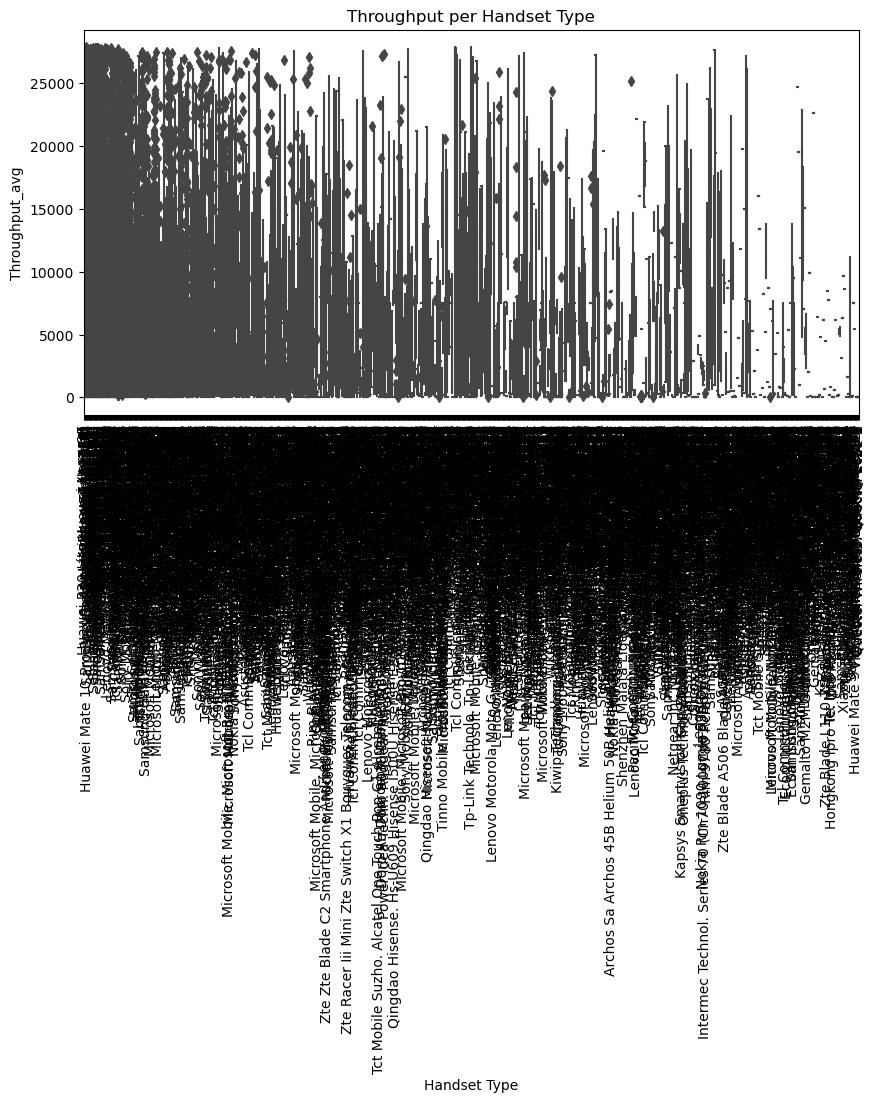

In [45]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Handset Type', y='Throughput_avg', data=user_exp)
plt.xticks(rotation=90)
plt.title("Throughput per Handset Type")
plt.show()

### Interpretation
* Some devices show higher throughput → better hardware optimization
* Low-performing devices → target for upgrades

##### TCP per Handset

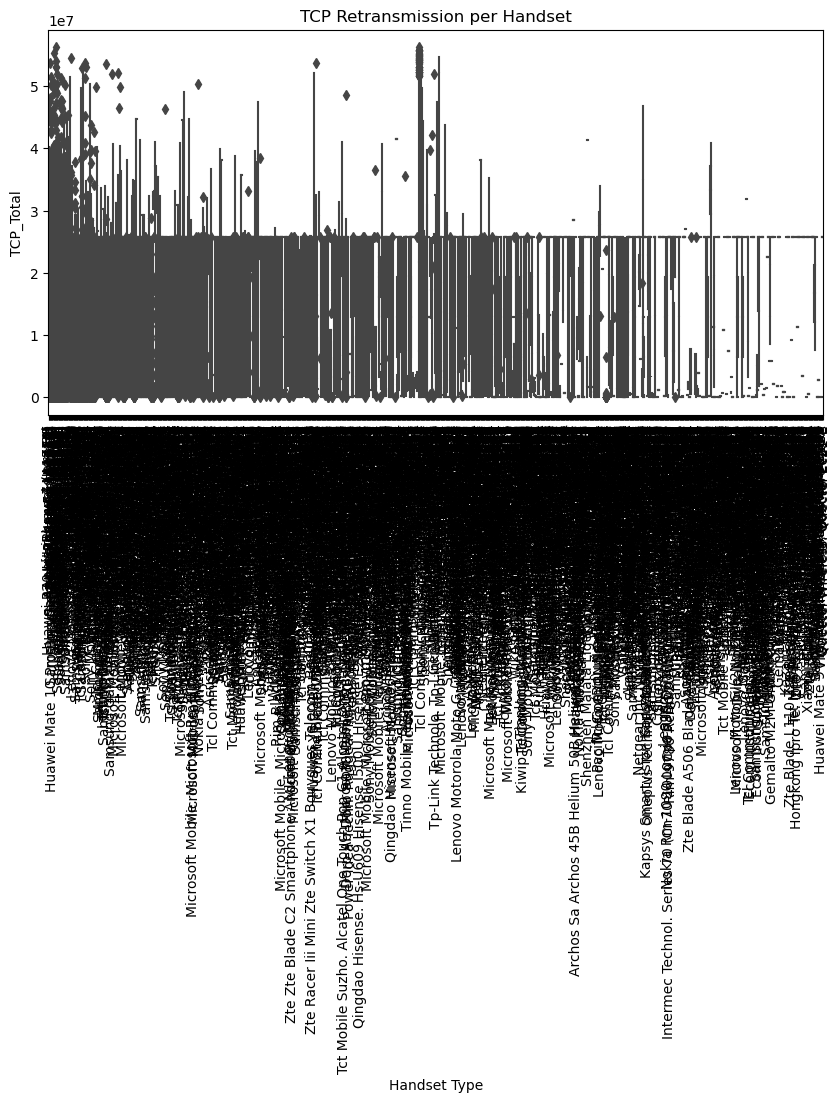

In [46]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Handset Type', y='TCP_Total', data=user_exp)
plt.xticks(rotation=90)
plt.title("TCP Retransmission per Handset")
plt.show()

### Interpretation

* High TCP = network issues OR device inefficiency
* Helps identify problematic handset models

### TASK 3.4 - K-Means Clustering

##### Normalize Data

In [47]:
from sklearn.preprocessing import StandardScaler

features = user_exp[['TCP_Total', 'RTT_avg', 'Throughput_avg']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

##### Apply K-Means (k = 3)

In [48]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
user_exp['experience_cluster'] = kmeans.fit_predict(scaled_features)

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [49]:
print(user_exp.columns)

Index(['MSISDN/Number', 'TCP_Total', 'RTT_avg', 'Throughput_avg',
       'Handset Type', 'experience_cluster'],
      dtype='object')


##### Cluster Summary

In [50]:
cluster_summary = user_exp.groupby('experience_cluster').mean(numeric_only=True)
print(cluster_summary)

                    MSISDN/Number     TCP_Total    RTT_avg  Throughput_avg
experience_cluster                                                        
0                    3.367288e+10  2.468442e+07  22.047953     1276.845685
1                    7.719377e+10  2.503755e+07  64.187652     1199.348229
2                    3.367574e+10  5.430662e+06  47.967652    11097.682506


### CLUSTER INTERPRETATION
1. Cluster 0 – Poor Experience
* High TCP retransmission
* High RTT
* Low throughput
* Users facing network issues
2. Cluster 1 – Moderate Experience
* (medium) TCP & RTT
* Average throughput
* Normal users
3. Cluster 2 – Good Experience
* Low TCP
* Low RTT
* High throughput
* Best network experience users

### BUSINESS INSIGHTS (Task 3)
* Key Findings
1. Network performance varies significantly across users
2. Some handset types underperform → optimization needed
3. Poor experience clusters exist → risk of churn
* Recommendations
1. Improve infrastructure for high RTT areas
2. Optimize network for low-performing devices
3. Prioritize high-value users with poor experience
4. Enhance QoS for video-heavy users

## Task 4: Satisfaction Analysis

### Task 4.1(a) - Engagement Score
* Engagement score = distance from LESS engaged cluster

In [51]:
from scipy.spatial.distance import cdist

# Get cluster centers (from Task 2)
eng_centers = kmeans.cluster_centers_

# Identify least engaged cluster (lowest sum of metrics)
eng_cluster_avg = engagement_df.groupby('cluster')[['session_frequency','Dur. (ms)','total_traffic']].mean()
least_eng_cluster = eng_cluster_avg.sum(axis=1).idxmin()

least_eng_center = eng_centers[least_eng_cluster]

# Compute Euclidean distance
engagement_df['engagement_score'] = cdist(
    engagement_norm_df,
    [least_eng_center],
    metric='euclidean'
)
print (engagement_df['engagement_score'])

0         1.763933
1         1.812704
2         1.782814
3         1.795532
4         1.774608
            ...   
106851    1.776012
106852    1.790660
106853    1.801196
106854    1.781654
106855    1.807784
Name: engagement_score, Length: 106856, dtype: float64


### Task 4.1(b) - Experience Score
* Experience score = distance from WORST experience cluster

In [53]:
# Identify worst experience cluster
exp_cluster_avg = user_exp.groupby('experience_cluster')[['TCP_Total','RTT_avg','Throughput_avg']].mean()

# Worst = high TCP + RTT, low throughput
worst_cluster = exp_cluster_avg[['TCP_Total','RTT_avg']].sum(axis=1).idxmax()

# Get centers
exp_centers = kmeans.cluster_centers_  # (reuse or define separately if needed)
worst_center = exp_centers[worst_cluster]

# Compute score
from scipy.spatial.distance import cdist

user_exp['experience_score'] = cdist(
    scaled_features,
    [worst_center],
    metric='euclidean'
)
print (user_exp['experience_score'])

0         1.808406
1         2.133863
2         0.199036
3         0.985965
4         1.728880
            ...   
106851    3.053034
106852    1.938280
106853    0.206191
106854    0.203801
106855    0.206116
Name: experience_score, Length: 106856, dtype: float64


### TASK 4.2 - Satisfaction Score

In [54]:
# Merge both datasets
final_df = engagement_df.merge(user_exp[['MSISDN/Number','experience_score']], on='MSISDN/Number')

# Satisfaction score
final_df['satisfaction_score'] = (
    final_df['engagement_score'] + final_df['experience_score']
) / 2

# Top 10 satisfied users
top_10_satisfied = final_df.nlargest(10, 'satisfaction_score')
print(top_10_satisfied)

       MSISDN/Number  session_frequency  Dur. (ms)  Total DL (Bytes)  \
20334   3.364337e+10                  1    14852.0        33399557.0   
51587   3.366317e+10                  1    77169.0       318380057.0   
46010   3.366187e+10                  1    86399.0        32639379.0   
16364   3.363149e+10                  1    56218.0       178775571.0   
63402   3.366660e+10                  1    34436.0       531811123.0   
42421   3.366099e+10                  1    24659.0       475509591.0   
60258   3.366551e+10                  1    86399.0       830832881.0   
94279   3.376115e+10                  1    31427.0       315536186.0   
99994   3.376359e+10                  1    86399.0       705154473.0   
70294   3.366885e+10                  1    86399.0       839553264.0   

       Total UL (Bytes)  total_traffic  cluster  engagement_score  \
20334        26274424.0     59673981.0        2          1.821130   
51587        43168560.0    361548617.0        2          1.799458   


### Interpretation
* High score = high engagement + good experience
* These are your VIP users

### TASK 4.3 - Regression Model

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Features & target
X = final_df[['session_frequency','Dur. (ms)','total_traffic','experience_score']]
y = final_df['satisfaction_score']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Metrics
print("R2:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))

R2: 0.9999896930900204
RMSE: 0.00174250087162676


### Interpretation
* High R² → good predictive power
* Helps predict future user satisfaction

### Task 4.4 - K-Means on Scores

In [56]:
from sklearn.cluster import KMeans

score_features = final_df[['engagement_score','experience_score']]

kmeans2 = KMeans(n_clusters=2, random_state=42)
final_df['satisfaction_cluster'] = kmeans2.fit_predict(score_features)
print (final_df['satisfaction_cluster'] )

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


0         0
1         0
2         1
3         1
4         0
         ..
106851    0
106852    0
106853    1
106854    1
106855    1
Name: satisfaction_cluster, Length: 106856, dtype: int32


### Task 4.5 - Cluster Aggregation

In [57]:
cluster_summary = final_df.groupby('satisfaction_cluster').agg({
    'satisfaction_score': 'mean',
    'experience_score': 'mean'
})

print(cluster_summary)

                      satisfaction_score  experience_score
satisfaction_cluster                                      
0                               2.114200          2.432166
1                               1.176251          0.557657


### Interpretation
a) Cluster 0 → Low Satisfaction
* Needs improvement

b) Cluster 1 → High Satisfaction
* Loyal users

### Task 4.6 - Export Final table (dataset containing all user ID + engagement, experience & satisfaction scores) in local MySQL database

In [58]:
# Create final dataset with required columns

final_dataset = final_df[[
    'MSISDN/Number',
    'engagement_score',
    'experience_score',
    'satisfaction_score'
]].copy()

# Rename columns
final_dataset.rename(columns={
    'MSISDN/Number': 'user_id'
}, inplace=True)

# Ensure correct data types
final_dataset['user_id'] = final_dataset['user_id'].astype(str)
final_dataset['engagement_score'] = final_dataset['engagement_score'].astype(float)
final_dataset['experience_score'] = final_dataset['experience_score'].astype(float)
final_dataset['satisfaction_score'] = final_dataset['satisfaction_score'].astype(float)

# Preview
print(final_dataset.head())

         user_id  engagement_score  experience_score  satisfaction_score
0  33601001722.0          1.763933          1.808406            1.786169
1  33601001754.0          1.812704          2.133863            1.973284
2  33601002511.0          1.782814          0.199036            0.990925
3  33601007832.0          1.795532          0.985965            1.390749
4  33601008617.0          1.774608          1.728880            1.751744


In [61]:
# ----------------------------
# SAVE FILE
# ----------------------------
final_dataset.to_csv("final_df.csv", index=False)

print("✅ final_df.csv created successfully!")

✅ final_df.csv created successfully!


In [60]:
import os
print(os.getcwd())

c:\Users\HP\Downloads


In [95]:
pip install pyodbc sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [96]:
from sqlalchemy import create_engine

In [109]:
# Define SQL Server connection details
server = 'DESKTOP-MLAFN1T\SQLEXPRESS' # The name of my server
database = 'master' # The database I want to connect to



In [110]:
# Create a connection string with a trusted connection
connection_url = f"mssql+pyodbc://@{server}/{database}?driver=ODBC+Driver+17+for+SQL+Server&trusted+connection=yes&TrustServerCertificate=yes"

In [111]:
# Create an engine
engine = create_engine(connection_url)

In [112]:
# Transfer data to SQL server
table_name = 'telecom_dataset'
final_dataset.to_sql(table_name, engine, if_exists='replace', index=False)

-1

In [113]:
# Confirm completion
print (f"Datset transferred to SQL Server table: {table_name}")

Datset transferred to SQL Server table: telecom_dataset


In [114]:
# Dispose the engine
engine.dispose()

### Task 4.7 - Model Deployment & Tracking

#### Simple MLOps using CSV Logging

In [122]:
import datetime

log = {
    "model": "LinearRegression",
    "start_time": str(datetime.datetime.now()),
    "r2_score": r2_score(y_test, y_pred),
    "rmse": mean_squared_error(y_test, y_pred, squared=False)
}

log_df = pd.DataFrame([log])
log_df.to_csv("model_tracking.csv", mode='a', index=False)

In [1]:
import os
print(os.getcwd())

c:\Users\HP\Downloads


In [2]:
# ----------------------------
# TRAIN TEST SPLIT
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# ----------------------------
# MODEL
# ----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# ----------------------------
# PREDICTION
# ----------------------------
y_pred = model.predict(X_test)

# ----------------------------
# METRICS
# ----------------------------
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

# ----------------------------
# END TIME
# ----------------------------
end_time = datetime.datetime.now()

# ----------------------------
# SAVE MODEL (ARTIFACT)
# ----------------------------
joblib.dump(model, "model.pkl")

# ----------------------------
# LOGGING
# ----------------------------
log = {
    "code_version": "v1.0",
    "start_time": str(start_time),
    "end_time": str(end_time),
    "data_source": "final_df.csv",
    "model": "LinearRegression",
    "parameters": "default",
    "r2_score": r2,
    "rmse": rmse,
    "artifact": "model.pkl"
}

log_df = pd.DataFrame([log])

file_exists = os.path.isfile("model_tracking.csv")

log_df.to_csv(
    "model_tracking.csv",
    mode='a',
    header=not file_exists,
    index=False
)

print("✅ Model training + tracking completed!")

NameError: name 'train_test_split' is not defined

In [1]:
import os
print(os.getcwd())

c:\Users\HP\Downloads
